# Binary Classification U-Net for Brain Tumor Detection

- The model outputs two logits per input, which are converted via Softmax into probabilities for the classes ["no tumor", "tumor"].

In [1]:
from data import load_mri_dataframe, get_dataloader_binarytransformed


df = load_mri_dataframe()
cls_train_loader, cls_val_loader = get_dataloader_binarytransformed(df, batch_size=8, transform=None)

print(f"Train Samples: {len(cls_train_loader.dataset)} | Val Samples: {len(cls_val_loader.dataset)}")

[Data] (Binary) Train samples: 3143 ; Val samples: 786
Train Samples: 3143 | Val Samples: 786


In [2]:
import torch
import torch.nn as nn
from torchvision.models import vgg16, VGG16_Weights

class VGG16(nn.Module):
    """
    VGG16-based classification model for brain tumor detection.
    
    Outputs:
        logits (batch x 2)  – raw, pre-Softmax scores for the classes ['no tumor', 'tumor']
    """
    def __init__(self, dropout_prob=0.3, freeze_features=True):
        super().__init__()
        base = vgg16(weights=VGG16_Weights.DEFAULT)
        self.features = base.features
        self.avgpool  = base.avgpool

        if freeze_features:
            for p in self.features.parameters():
                p.requires_grad = False

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_prob),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_prob),
   
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        logits = self.classifier(x)

        return logits

In [3]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
  

model = VGG16(freeze_features=True)
model.to(device)
print(f"Device: {device}.")

Device: cuda.


In [4]:
import torch.optim as optim
from train_generalized import train


trained_model, training_results = train(
    model,
    cls_train_loader,
    cls_val_loader,
    device,
    epochs=5,
    lr=1e-3,
    optimizer_class=optim.Adam,
    loss_fn = nn.CrossEntropyLoss,
    task="classification",
    save_name="binary_classification_model"
)



Epoch 1/5: 100%|█| 393/393 [00:08<00:00, 45.12it/s, train_acc=0.7703, train_loss


Epoch 1/5 - Avg Train Loss: 0.4652


Epoch 2/5: 100%|█| 393/393 [00:08<00:00, 45.18it/s, train_acc=0.8209, train_loss


Epoch 2/5 - Avg Train Loss: 0.3560


Epoch 3/5: 100%|█| 393/393 [00:08<00:00, 45.03it/s, train_acc=0.8460, train_loss


Epoch 3/5 - Avg Train Loss: 0.3212


Epoch 4/5: 100%|█| 393/393 [00:08<00:00, 45.00it/s, train_acc=0.8804, train_loss


Epoch 4/5 - Avg Train Loss: 0.2527


Epoch 5/5: 100%|█| 393/393 [00:08<00:00, 44.05it/s, train_acc=0.8864, train_loss


Epoch 5/5 - Avg Train Loss: 0.2420


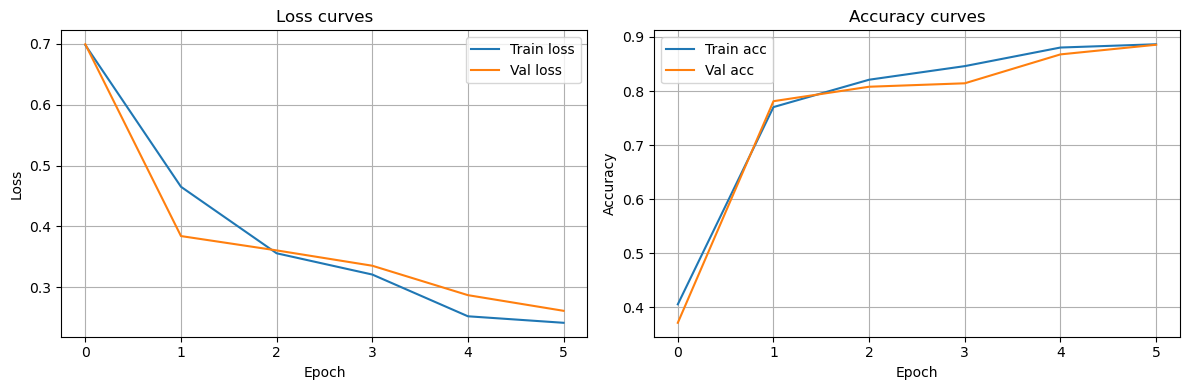

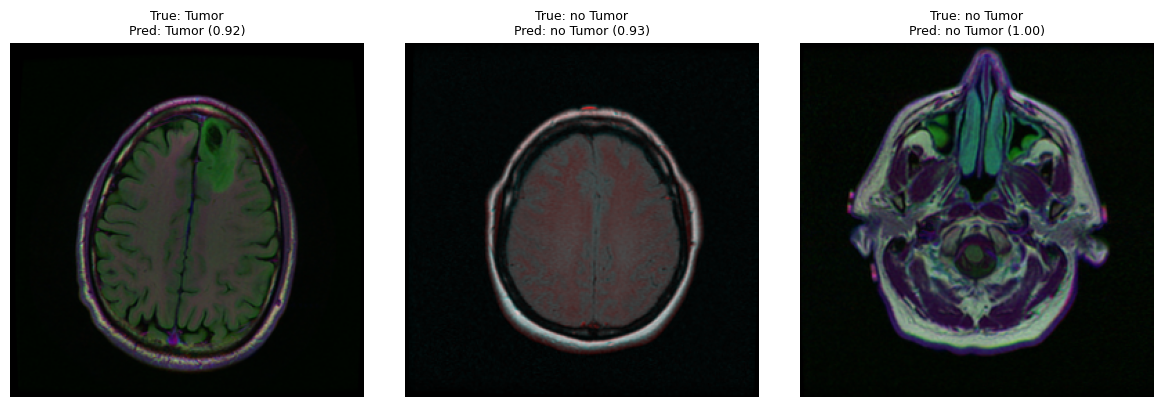

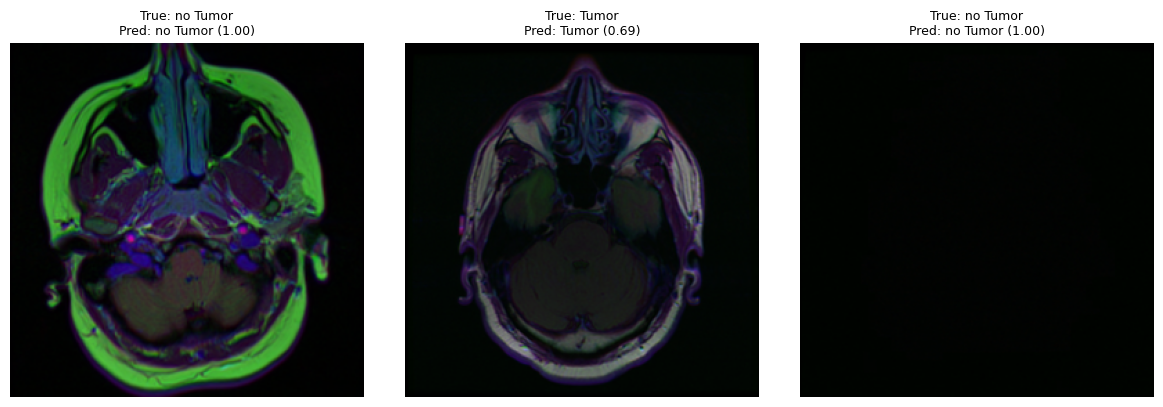

Final Val Accuracy: 0.8855


In [5]:
from eval import evaluate_classification 
class_names = ["no Tumor", "Tumor"]
evaluate_classification(
    results=training_results,
    num_batches=2,
    class_names=class_names
)